In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("ai_resume_screening.csv")

In [3]:
print(df.shape)

(30000, 7)


In [4]:
edu_encoder = LabelEncoder()
df['education_level'] = edu_encoder.fit_transform(df['education_level'])

In [5]:
target_encoder = LabelEncoder()
df['shortlisted'] = target_encoder.fit_transform(df['shortlisted'])

In [6]:
print("✅ Text categories successfully converted to numbers.")

✅ Text categories successfully converted to numbers.


In [7]:
X = df.drop('shortlisted', axis=1)
y = df['shortlisted']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data split complete: Training on {X_train.shape[0]} rows, Testing on {X_test.shape[0]} rows.")

✅ Data split complete: Training on 24000 rows, Testing on 6000 rows.


In [9]:
# Display the first 5 rows of our training features
display(X_train.head())

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity
21753,12,100.0,2,13,717,469
251,8,59.5,0,10,595,418
22941,3,56.0,2,8,303,195
618,14,87.9,3,14,770,435
17090,5,68.8,2,10,277,255


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
#initialised random forest 

In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [12]:
rf_model.fit(X_train, y_train)
print("✅ Model training complete!")

✅ Model training complete!


In [13]:
predictions = rf_model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, predictions)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%\n")


Model Accuracy: 89.85%



In [15]:
print("Detailed Performance Report:")
print(classification_report(y_test, predictions, target_names=['Not Shortlisted', 'Shortlisted']))

Detailed Performance Report:
                 precision    recall  f1-score   support

Not Shortlisted       0.84      0.82      0.83      1832
    Shortlisted       0.92      0.93      0.93      4168

       accuracy                           0.90      6000
      macro avg       0.88      0.88      0.88      6000
   weighted avg       0.90      0.90      0.90      6000



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [17]:
importances = rf_model.feature_importances_
features = X.columns

In [18]:
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12980\492670426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako')


<Axes: xlabel='Importance', ylabel='Feature'>

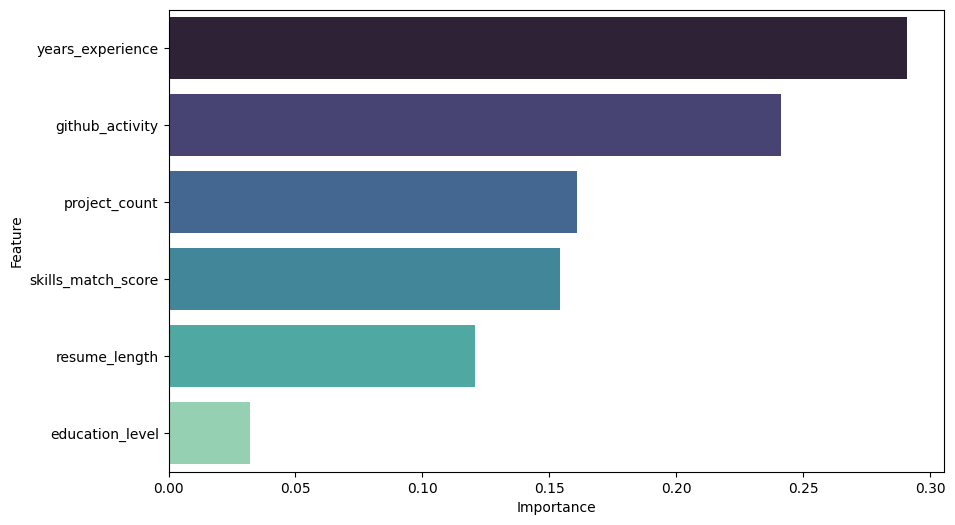

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako')

Text(0, 0.5, 'Candidate Stats')

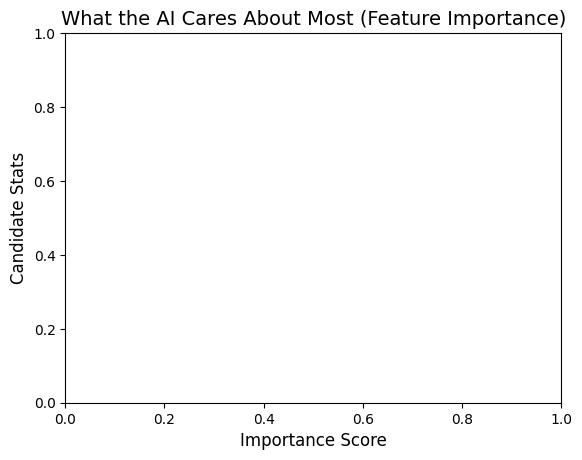

In [20]:
plt.title('What the AI Cares About Most (Feature Importance)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Candidate Stats', fontsize=12)

In [21]:
plt.show()

In [22]:
import pandas as pd

# 1. Create a fictional candidate's resume stats
# Feel free to change these numbers to see how the AI reacts!
new_candidate = {
    'years_experience': [4],           # 4 years of experience
    'skills_match_score': [82.5],      # 82.5% keyword match with job description
    'education_level': ['Masters'],    # Must be 'Bachelors', 'Masters', 'High School', or 'PhD'
    'project_count': [5],              # 5 portfolio projects
    'resume_length': [350],            # 350 words long
    'github_activity': [110]           # 110 commits/contributions
}

In [23]:
candidate_df = pd.DataFrame(new_candidate)

In [24]:
candidate_df['education_level'] = edu_encoder.transform(candidate_df['education_level'])

In [25]:
prediction = rf_model.predict(candidate_df)

In [26]:
final_decision = target_encoder.inverse_transform(prediction)

In [27]:
print("🤖 AI Decision Process Complete.")
print(f"➡️ Will this candidate be shortlisted? {final_decision[0]}")

🤖 AI Decision Process Complete.
➡️ Will this candidate be shortlisted? Yes


In [28]:
import joblib

joblib.dump(rf_model, 'resume_screening_model.pkl')

joblib.dump(edu_encoder, 'edu_encoder.pkl')
joblib.dump(target_encoder, 'target_encoder.pkl')

print("✅ Model and encoders successfully saved to your computer!")

✅ Model and encoders successfully saved to your computer!
